In [2]:
# ✅ Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import random

sns.set(style="whitegrid")

In [3]:
# ✅ Step 2: Create a Large Synthetic Dataset (Graph Data)
# Simulate a network of 50 web pages (Page_1 ... Page_50)
nodes = [f"Page_{i}" for i in range(1, 51)]

# Create random directed edges (simulate hyperlinks)
edges = []
for _ in range(250):   # 250 random links
    src = random.choice(nodes)
    dest = random.choice(nodes)
    if src != dest:
        edges.append((src, dest))

# Convert to DataFrame for readability
edges_df = pd.DataFrame(edges, columns=["From_Page", "To_Page"])

print("✅ Synthetic Web Network Dataset Created Successfully!\n")
print("Dataset Shape:", edges_df.shape)
print("\nSample of Dataset:\n")
print(edges_df.head(10))


✅ Synthetic Web Network Dataset Created Successfully!

Dataset Shape: (247, 2)

Sample of Dataset:

  From_Page  To_Page
0    Page_9  Page_24
1   Page_17  Page_20
2   Page_42  Page_32
3   Page_16   Page_4
4    Page_4   Page_7
5   Page_18  Page_48
6   Page_49  Page_28
7   Page_14  Page_19
8   Page_25  Page_48
9    Page_2  Page_47


C:\Users\VAIBHAV ADMANE\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


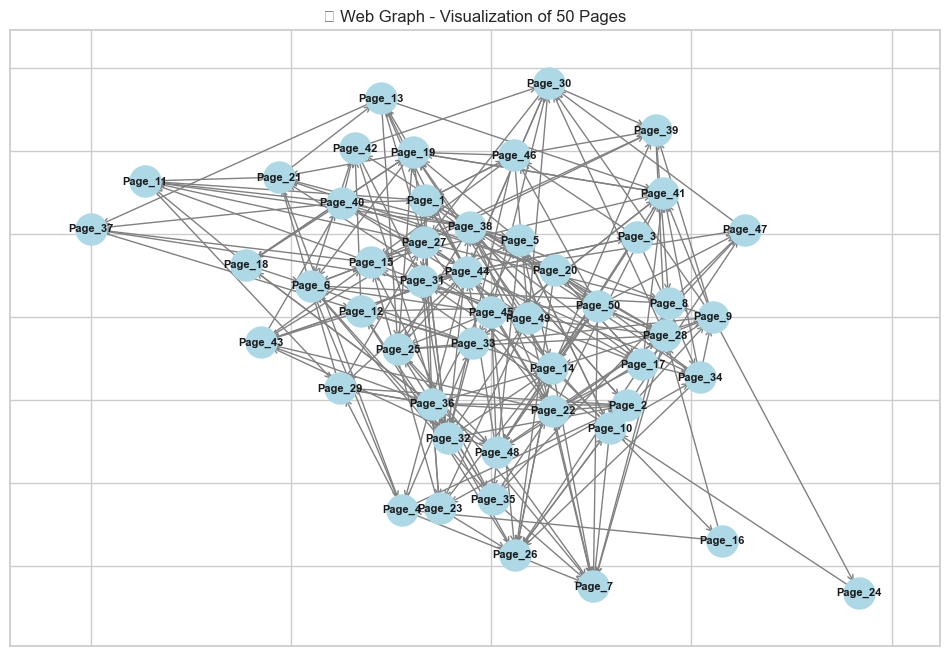

In [4]:
# ✅ Step 3: Visualize the Web Graph (Initial Network)
G = nx.DiGraph()
G.add_edges_from(edges)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=500, node_color='lightblue')
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=10, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')
plt.title("🌐 Web Graph - Visualization of 50 Pages")
plt.show()

In [5]:
# ✅ Step 4: Implement the PageRank Algorithm (Manual)
# Formula:
# PR(A) = (1 - d)/N + d * Σ [ PR(B) / L(B) ]
# where:
#   d = damping factor
#   N = total number of pages
#   L(B) = number of outbound links from page B

def manual_pagerank(graph, damping=0.85, max_iter=100, tol=1e-6):
    N = len(graph)
    ranks = dict.fromkeys(graph, 1.0 / N)

    for iteration in range(max_iter):
        prev_ranks = ranks.copy()
        for node in graph:
            rank_sum = 0.0
            # Sum contributions from inbound links
            for neighbor in graph.predecessors(node):
                out_degree = len(list(graph.successors(neighbor)))
                if out_degree > 0:
                    rank_sum += prev_ranks[neighbor] / out_degree

            ranks[node] = (1 - damping) / N + damping * rank_sum

        # Check for convergence
        diff = sum(abs(ranks[n] - prev_ranks[n]) for n in graph)
        if diff < tol:
            print(f"✅ Converged after {iteration + 1} iterations")
            break
    return ranks

pagerank_scores = manual_pagerank(G)

✅ Converged after 15 iterations


In [6]:
# ✅ Step 5: Convert PageRank Results into DataFrame
pagerank_df = pd.DataFrame(list(pagerank_scores.items()), columns=["Page", "PageRank_Score"])
pagerank_df.sort_values("PageRank_Score", ascending=False, inplace=True)
pagerank_df.reset_index(drop=True, inplace=True)

print("\n✅ PageRank Scores Computed Successfully!\n")
print(pagerank_df.head(10))


✅ PageRank Scores Computed Successfully!

      Page  PageRank_Score
0  Page_32        0.034077
1  Page_25        0.033528
2  Page_41        0.033213
3  Page_22        0.033198
4   Page_7        0.031063
5  Page_19        0.030474
6   Page_6        0.030050
7  Page_44        0.029978
8  Page_12        0.029822
9  Page_28        0.028548


C:\Users\VAIBHAV ADMANE\AppData\Local\Temp\ipykernel_23008\3328347488.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pagerank_df.head(15), x="PageRank_Score", y="Page", palette="coolwarm")


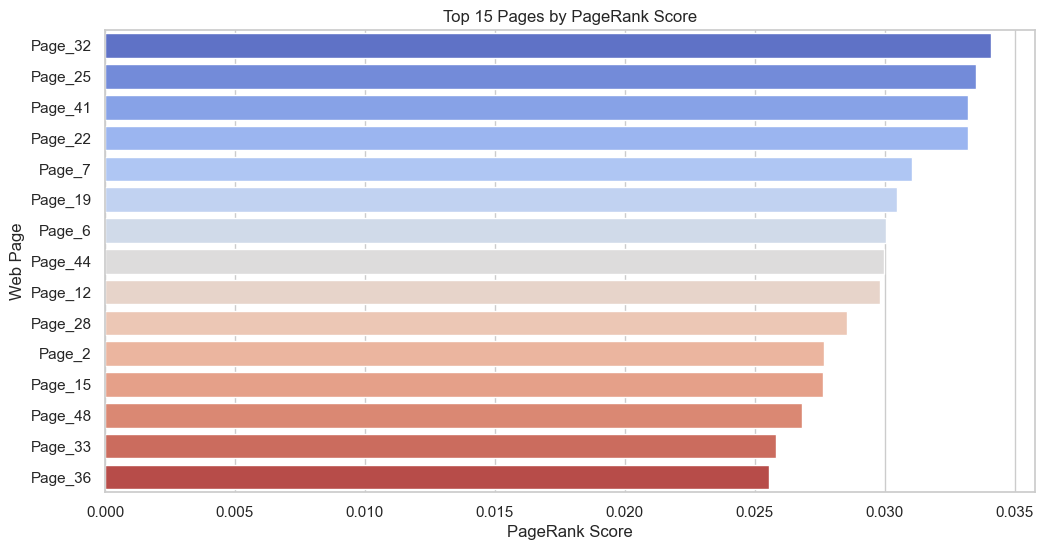

In [7]:
# ✅ Step 6: Visualize Top 15 PageRank Scores (Bar Plot)
plt.figure(figsize=(12, 6))
sns.barplot(data=pagerank_df.head(15), x="PageRank_Score", y="Page", palette="coolwarm")
plt.title("Top 15 Pages by PageRank Score")
plt.xlabel("PageRank Score")
plt.ylabel("Web Page")
plt.show()

C:\Users\VAIBHAV ADMANE\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


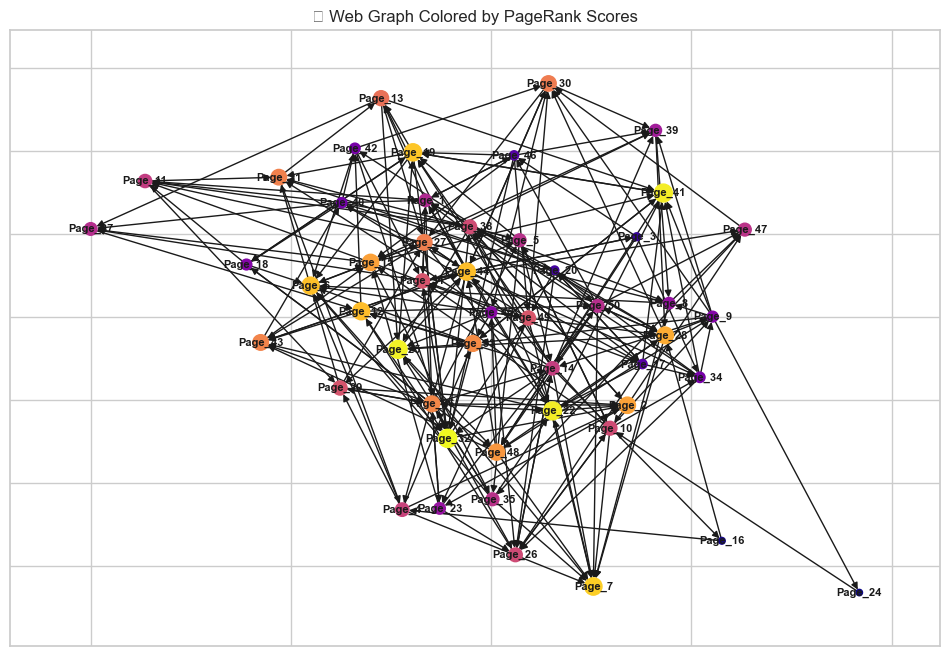

In [8]:
# ✅ Step 7: Visualize the Graph with PageRank Weights
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)
node_sizes = [v * 5000 for v in pagerank_scores.values()]
nx.draw_networkx(
    G, pos,
    node_size=node_sizes,
    node_color=list(pagerank_scores.values()),
    cmap=plt.cm.plasma,
    with_labels=True,
    font_size=8,
    font_weight="bold",
    arrows=True
)
plt.title("🌐 Web Graph Colored by PageRank Scores")
plt.show()

In [9]:
# ✅ Step 8: Compare Manual Results with NetworkX PageRank
nx_pagerank = nx.pagerank(G, alpha=0.85)
nx_pagerank_df = pd.DataFrame(list(nx_pagerank.items()), columns=["Page", "NetworkX_PageRank"])
nx_pagerank_df.sort_values("NetworkX_PageRank", ascending=False, inplace=True)

# Merge for comparison
comparison = pagerank_df.merge(nx_pagerank_df, on="Page")
comparison["Difference"] = abs(comparison["PageRank_Score"] - comparison["NetworkX_PageRank"])

print("\n✅ Comparison Between Manual & NetworkX PageRank:\n")
print(comparison.head(10))


✅ Comparison Between Manual & NetworkX PageRank:

      Page  PageRank_Score  NetworkX_PageRank    Difference
0  Page_32        0.034077           0.034076  6.856417e-07
1  Page_25        0.033528           0.033528  4.273205e-07
2  Page_41        0.033213           0.033214  9.481935e-07
3  Page_22        0.033198           0.033198  1.646091e-07
4   Page_7        0.031063           0.031063  1.711091e-07
5  Page_19        0.030474           0.030475  6.798429e-07
6   Page_6        0.030050           0.030050  1.158296e-07
7  Page_44        0.029978           0.029979  5.717878e-07
8  Page_12        0.029822           0.029824  1.144745e-06
9  Page_28        0.028548           0.028548  4.242063e-07


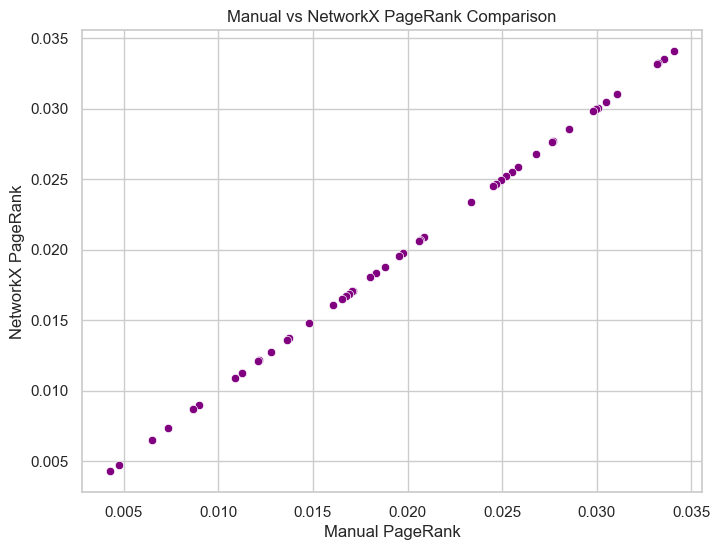

In [10]:
# ✅ Step 9: Visualize Comparison (Scatter Plot)
plt.figure(figsize=(8,6))
sns.scatterplot(data=comparison, x="PageRank_Score", y="NetworkX_PageRank", color="purple")
plt.title("Manual vs NetworkX PageRank Comparison")
plt.xlabel("Manual PageRank")
plt.ylabel("NetworkX PageRank")
plt.show()

In [11]:
# ✅ Step 10: Save PageRank Results
pagerank_df.to_csv("PageRank_Output.csv", index=False)
print("\n✅ PageRank results saved as 'PageRank_Output.csv' successfully!")



✅ PageRank results saved as 'PageRank_Output.csv' successfully!
